# Where to Blitz the Gap — a walkthrough

*What is in the tool, and why is it built the way it is.*

[Where to Blitz the Gap](https://wietzesuijker.github.io/where-to-blitz/) is a companion
planning tool for the Canada-wide [Blitz the Gap](https://blitzthegap.org) iNaturalist
bioblitz. It turns one question — *"where should I go to record biodiversity so my
observation adds the most to what we know about Canada?"* — into a map you can weight,
explore, and plan a real low-carbon trip on.

If you build, score, or run the campaign — this is the methodology and the data underneath it,
laid out so you can check every choice and reproduce every number.

> It is a **work-in-progress prototype, not an official Blitz the Gap tool, and not ground truth.**
> It is a *planning aid*. The responsible-use guardrails are part of the design, not an afterthought (last section).

This walkthrough is **not** about the modelling pipeline in the abstract. The moat is the
**set of choices** that make the map trustworthy and the **contents** those choices produce.
Each section pairs a design decision with the real data it acts on. Everything below runs
from the committed build — re-execute top to bottom to reproduce every figure.

## 0 · Zoom out — the whole tool in one picture

How a question becomes a map you can act on:

```mermaid
flowchart TB
  Q(["🧭 <b>Where should I record wildlife<br/>so it helps Canada the most?</b>"])
  subgraph DATA["① Free, public data — no logins, no private files"]
    direction LR
    D1["iNaturalist<br/>sightings"]
    D2["Climate"]
    D3["Forest<br/>loss"]
    D4["Roads &<br/>travel time"]
    D5["At-risk<br/>species lists"]
  end
  GOALS["② Split Canada into 25 km squares.<br/>Score each square on <b>5 goals</b> (0–1):<br/>find new species · find rare species ·<br/>cover every habitat · revisit quiet spots · beat habitat loss"]
  IMPACT["③ <b>You</b> choose how much each goal matters.<br/>→ one <b>0–100 'impact' score</b> per square"]
  APP(["④ <b>The map</b><br/>🗺️ Explore  ·  🚗 Plan a trip  ·  📊 Compare goals"])
  CHECK{{"✅ Reality-checked against a real bioblitz:<br/>do its top spots actually find more species? <b>Yes.</b>"}}

  Q --> DATA --> GOALS --> IMPACT --> APP
  GOALS -. "validated" .-> CHECK

  style Q fill:#1b4965,color:#fff,stroke:#1b4965
  style APP fill:#2a9d4a,color:#fff,stroke:#2a9d4a
  style CHECK fill:#eaf4ea,stroke:#2a9d4a
```

**In one breath:** the tool turns six free public datasets into a score for every 25 km
square of Canada, lets *you* weight what "worth visiting" means, and points you to the best
spot you can actually reach — and its choices are checked against a real bioblitz, not just
asserted. The rest of this notebook opens each box: what's in a square, why each goal is
scored the way it is, and the evidence behind the headline.

<details><summary><b>Under the hood</b> — the modules a developer would touch</summary>

| Module | Responsible for |
|---|---|
| `build_fullgrid_ca.py` | The four raster goals per square — **discover, habitat coverage, urgency, travel** — plus `n_train`. Defines the grid + land mask. |
| `build_atrisk_layer.py` + `join_conservation.py` | The **rare-species** goal: CAN-SAR (COSEWIC/SARA) species × their GBIF occurrences → per-square status-weighted at-risk richness, aggregated to 25 km. |
| cluster DuckDB → `ca_inat_metrics.csv` → `build_staleness_layer.py` | The **freshness** goal: all-time vs last-5-years iNaturalist density per square. |
| `build_webapp.py` | The single source of truth for the app. Combines the five goals into **impact** (a percentile rank), holds every UI string (EN/FR), the trip planner, and emits `index.html`. |
| `build_provenance.py` | Freezes the national build to a hashed manifest (`provenance.json`). |
| `voi_backtest.py`, `backtest_appscore.py` | The validation layer: do gap-filling priorities actually discover more than going where it's already busy? |

</details>

In [1]:
# Setup — all paths relative to the repo root (run this notebook from there).
import json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": False})

CA = Path("cluster_results/ca")
RES = Path("cluster_results")
INDEX = json.load(open(CA / "index.json"))
PROV  = json.load(open(CA / "provenance.json"))

# row_format from the shipped index — the contract every webapp_data_*.json obeys.
COLS = INDEX["row_format"]            # [lat,lon,discover,conservation,env,staleness,urgency,travel_min,n_train]
AXES = ["discover", "conservation", "env", "staleness", "urgency"]
print("row format :", COLS)
print("axes       :", AXES)

def load_group(group="All biodiversity"):
    d = json.load(open(CA / f"webapp_data_{group.replace(' ', '_')}.json"))
    rows = d[list(d)[0]]
    return pd.DataFrame(rows, columns=COLS)

ALL = load_group("All biodiversity")
print(f"loaded {len(ALL):,} cells × {len(COLS)} columns for 'All biodiversity'")

# A reusable Canada scatter-map used throughout. Cells are points on the 0.25° grid;
# small squares read as a surface. ASPECT ~ 1/cos(59°N) keeps Canada from looking stretched.
LON, LAT = ALL["lon"].to_numpy(), ALL["lat"].to_numpy()
ASPECT = 1.7
def canada_map(ax, values, title, cmap="magma", vmax=None):
    ax.scatter(LON, LAT, c=values, s=2.0, marker="s", cmap=cmap, vmin=0, vmax=vmax, linewidths=0)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect(ASPECT)
    for s in ax.spines.values(): s.set_visible(False)

ALL.head(3)

row format : ['lat', 'lon', 'discover', 'conservation', 'env', 'staleness', 'urgency', 'travel_min', 'n_train']
axes       : ['discover', 'conservation', 'env', 'staleness', 'urgency']
loaded 31,804 cells × 9 columns for 'All biodiversity'


,lat,lon,discover,conservation,env,staleness,urgency,travel_min,n_train
0,41.125,-124.125,0.7270,0.0,0.627,0.31232,0.403,159.0,0
1,41.125,-123.875,0.6512,0.0,0.503,0.22263,0.058,176.0,0
2,41.125,-123.625,0.6013,0.0,0.399,0.22998,0.083,158.0,0


## 1 · What's in it — contents at a glance

Everything is one fixed geometry reused across life groups. A *cell* is the atom: a
0.25° (~25 km) square of Canadian land carrying five priority axes plus travel cost.

In [2]:
bbox = INDEX["bbox"]
print(f"Grid          : {INDEX['n_cells']:,} land cells, {INDEX['res']}° (~25 km)")
print(f"Extent        : lon {bbox[0]}…{bbox[2]}, lat {bbox[1]}…{bbox[3]} (all of Canada + a US land sliver)")
print(f"Life groups   : {len(INDEX['groups'])} → {', '.join(INDEX['groups'])}")
print(f"Per cell      : 5 axes (0–1) + travel_min + n_train")
print(f"Provenance    : {PROV['manifest_hash'][:16]}…  ({len(PROV['files'])} files frozen)")

# Verify the axes are REAL in the actual data (not from the doc, not from stale metadata):
print("\nAxis reality check (from the shipped data itself):")
for ax in AXES:
    col = ALL[ax].to_numpy(float)
    nz = (col != 0).mean()
    print(f"  {ax:13s} range [{col.min():.2f}, {col.max():.2f}]  nonzero in {nz*100:5.1f}% of cells")
stale_corr = np.corrcoef(ALL['discover'], ALL['staleness'])[0,1]
print(f"\n  staleness is NOT a copy of discover  →  corr(discover, staleness) = {stale_corr:+.3f}")
print(f"  conservation is a real sparse layer →  {(ALL['conservation']>0).sum():,} cells carry at-risk richness")

Grid          : 31,804 land cells, 0.25° (~25 km)
Extent        : lon -141.0…-52.0, lat 41.0…84.0 (all of Canada + a US land sliver)
Life groups   : 11 → All biodiversity, Plantae, Insecta, Aves, Fungi, Mammalia, Actinopterygii, Reptilia, Amphibia, Arachnida, Mollusca
Per cell      : 5 axes (0–1) + travel_min + n_train
Provenance    : 93f50ffa87672b40…  (27 files frozen)

Axis reality check (from the shipped data itself):
  discover      range [0.00, 1.00]  nonzero in 100.0% of cells
  conservation  range [0.00, 1.00]  nonzero in  10.4% of cells
  env           range [0.00, 1.00]  nonzero in  99.9% of cells
  staleness     range [0.00, 1.00]  nonzero in  28.1% of cells
  urgency       range [0.00, 1.00]  nonzero in  40.9% of cells

  staleness is NOT a copy of discover  →  corr(discover, staleness) = -0.385
  conservation is a real sparse layer →  3,292 cells carry at-risk richness


> **Honesty note (verified above, not asserted).** All five axes are real in the committed
> data. Two artifacts *lag* that truth and should be synced before release: the older
> `index.json` `axes_status` still labels conservation/staleness as placeholders, and two
> in-app slider hint strings (`OBJ[...]['q']`) still say "placeholder". The data, the
> `provenance.json`, the `axis_method` help block, and the *Most Wanted* / *Revisit the Past*
> presets all already use the real layers. (Flagged as a one-line product fix — it touches
> live public copy, so it's the user's call, not auto-pushed.)

## 2 · The data

Six public sources, each chosen because it is **fetchable without credentials** and
**national in coverage** — a hard constraint, because the tool must be reproducible by
anyone and must not depend on the private McGill iNat-Canada parquet.

| Axis | Source | What it is | Resolution | Licence / access |
|---|---|---|---|---|
| discover | iNaturalist observation density (Biodiversité Québec STAC) | per-group "light up the map" record density — the same surface the official project uses | 1 km COG | public COG on Arbutus |
| conservation | **CAN-SAR** (COSEWIC/SARA) × **GBIF** | 521 at-risk species × their Canadian occurrences | point → 25 km | CC-BY (OSF `10.17605/OSF.IO/E4A58`) + public GBIF |
| env | **CHELSA** bioclimate | temperature, seasonality, precipitation | ~1 km | public (`/vsicurl`) |
| staleness | **iNaturalist open-data** dump | per-record dates → all-time vs recent | per-record | public AWS dump |
| urgency | **Hansen** Global Forest Change | forest-loss fraction (logging / fire / dieback) | 0.05° | public |
| travel | **Weiss et al. 2018** accessibility | minutes to the nearest city | ~1 km | public (MalariaAtlas) |

A subtle but load-bearing data choice: the **land mask** is the Weiss travel raster's
ocean=nodata, intersected with Natural Earth coastlines *and* the iNat density COG footprint.
That last intersection dropped ~839 deep-US no-data cells that would otherwise have shown as
false gaps. The grid is a *decision*, not a given.

### 2.1 · Why the map spills into the United States

One thing you notice immediately: there is real data across Washington, Oregon, Idaho, Montana,
the Dakotas, Minnesota, Michigan, and Maine. That is **not a bug, but it is a known
consequence of two deliberate choices**, worth being explicit about:

1. **The grid is a rectangle whose southern edge is 41°N**, chosen to capture Canada's
   *southernmost* biodiversity hotspots — Point Pelee (41.9°N), the Carolinian zone, southern
   Vancouver Island. A latitude line at 41°N necessarily scoops up a band of the northern US.
2. **The land mask is *geographic*, not *political*.** `build_fullgrid_ca.py` keeps a cell if
   the Weiss travel-time raster says it's land (ocean = nodata) — it does **not** clip to the
   Canada polygon. The Natural Earth refinement only removed ocean and Greenland, keeping
   Canada **and** US land.

The important honesty point is *what the US data is and isn't*: the density layer is the
**Canada-focused** `inat_canada_heatmaps` COG. Its footprint spills a little across the border,
but the overwhelming majority of US cells sit **outside** the Canadian recording layer — so
they read as "gaps" largely because *the Canadian density layer stops at the border*, not
because they are genuinely under-recorded. (The team already dropped 839 *deep*-US cells that
were entirely outside the COG.) The figure quantifies it.

**The sharp horizontal seam along ~49°N is this, made visible — it's a data-footprint edge,
not ecology.** North of the border the Canadian density COG has records, so cells score on
real data (varied, mostly well-sampled). South of it the COG is empty, so every US cell
defaults into the same max-under-sampling bucket (differentiated only by climate) — a flat
band with a hard top edge. The transect below confirms it: density jumps from ~0 to thousands
and zero-observation cells go 95% → 0% across 48–49°N. A clip to the Canada polygon removes
both the US band and the seam in one move.

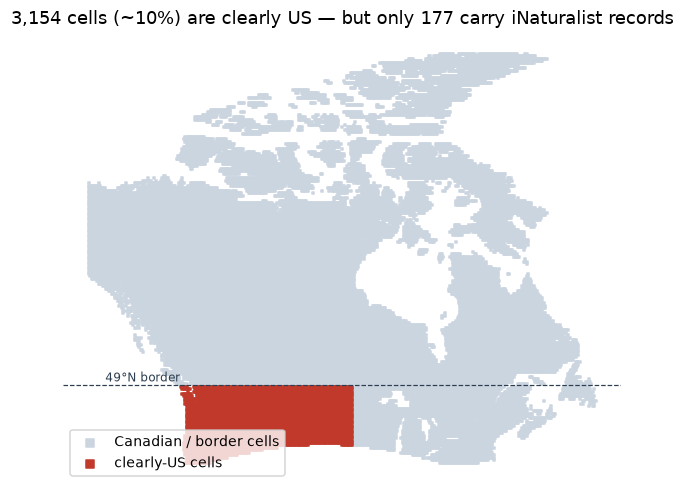

Clearly-US cells: 3,154  ·  of those with real iNat records: 177
→ Most US cells are gaps only because the Canadian density COG stops at the border.

Transect across the 49°N border (the visible seam):
   lat   n_train  %zero-obs  discover
US  47.5         0        98%      0.54
US  48.0       561        95%      0.51
US  48.5      2402        29%      0.27
CA  49.0      8271         0%      0.07
CA  49.5      2097         0%      0.08
→ density 0→thousands and zero-obs 95%→0% across the line = a data-footprint edge, not ecology.


In [3]:
us_west = (ALL["lon"] < -95) & (ALL["lat"] < 49.0)         # clearly-US band (W of -95, S of the 49th-parallel border)
n_us = int(us_west.sum()); n_us_rec = int((us_west & (ALL["n_train"] > 0)).sum())

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.scatter(ALL.lon[~us_west], ALL.lat[~us_west], s=2, marker="s", color="#cbd5e0", label="Canadian / border cells")
ax.scatter(ALL.lon[us_west],  ALL.lat[us_west],  s=2, marker="s", color="#c0392b", label="clearly-US cells")
ax.axhline(49, color="#2c3e50", lw=0.8, ls="--"); ax.text(-138, 49.4, "49°N border", fontsize=8, color="#2c3e50")
ax.set_aspect(ASPECT); ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values(): s.set_visible(False)
ax.legend(loc="lower left", fontsize=9, markerscale=4)
ax.set_title(f"{n_us:,} cells (~{us_west.mean()*100:.0f}%) are clearly US — but only {n_us_rec} carry iNaturalist records")
plt.tight_layout(); plt.show()
print(f"Clearly-US cells: {n_us:,}  ·  of those with real iNat records: {n_us_rec}")
print("→ Most US cells are gaps only because the Canadian density COG stops at the border.\n")

# Transect across the western border (lon -125..-100): the seam at ~49°N is the COG edge.
band = (ALL.lon > -125) & (ALL.lon < -100)
print("Transect across the 49°N border (the visible seam):")
print(f"{'lat':>6} {'n_train':>9} {'%zero-obs':>10} {'discover':>9}")
for lo in [47.5, 48.0, 48.5, 49.0, 49.5]:
    m = band & (ALL.lat >= lo) & (ALL.lat < lo + 0.5)
    side = "US " if lo < 49 else "CA "
    print(f"{side}{lo:5.1f} {ALL.n_train[m].mean():9.0f} {(ALL.n_train[m]==0).mean()*100:9.0f}% {ALL.discover[m].mean():9.2f}")
print("→ density 0→thousands and zero-obs 95%→0% across the line = a data-footprint edge, not ecology.")

## 3 · The five axes — what each one looks like over Canada

Each axis is scored **0–1 per cell**. Before the formulas, here is the actual content:
the five layers side by side. Read them as *"where does each goal send you?"* — they
disagree, which is the whole point of letting the user weight them (Section 6).

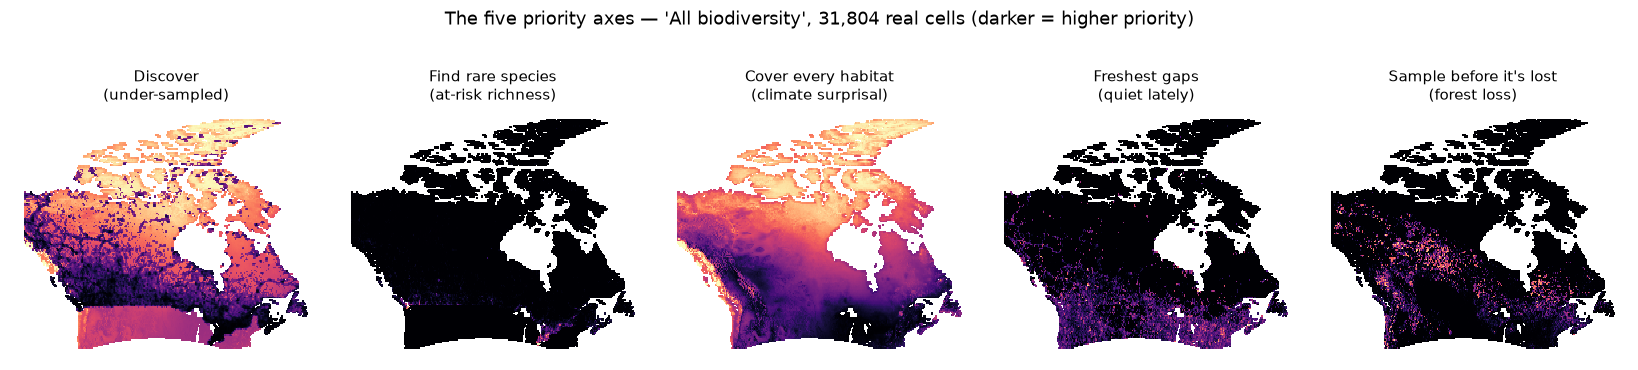

In [4]:
titles = {
    "discover":     "Discover\n(under-sampled)",
    "conservation": "Find rare species\n(at-risk richness)",
    "env":          "Cover every habitat\n(climate surprisal)",
    "staleness":    "Freshest gaps\n(quiet lately)",
    "urgency":      "Sample before it's lost\n(forest loss)",
}
fig, axs = plt.subplots(1, 5, figsize=(15, 3.6))
for ax, k in zip(axs, AXES):
    canada_map(ax, ALL[k], titles[k], cmap="magma")
fig.suptitle("The five priority axes — 'All biodiversity', 31,804 real cells (darker = higher priority)", y=1.02)
plt.tight_layout(); plt.show()

### 3.1 · Discover — and the **de-saturation choice**

**Measures:** how under-sampled a cell is. **Formula intent:** lower iNaturalist density →
higher discover.

**The choice.** The obvious formula is `norm(1 / (density + ε))`. We *don't* ship it. On the
real national density it is violently bimodal: ~half the cells have zero research-grade
records and pin at 1.0, while every recorded cell collapses to near-zero — the map becomes a
binary "recorded / not", with no gradient to plan a trip on. The shipped axis is instead a
**smooth under-sampling rank**, with zero-observation ties broken by climate distinctiveness
(`env`). The figure shows why the rank is the better content.

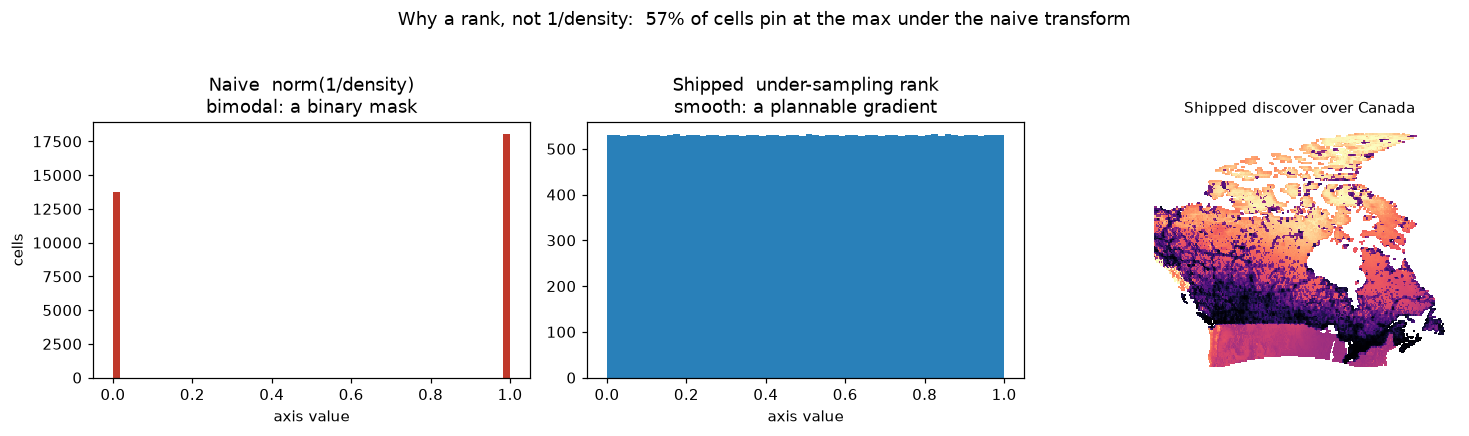

In [5]:
# n_train ≈ density × cell-area, so it's a faithful stand-in for the raw density the
# naive formula would have used. Compare the naive saturating transform to the shipped rank.
dens = ALL["n_train"].to_numpy(float)
naive = 1.0 / (dens + 1e-3)
naive = (naive - naive.min()) / (naive.max() - naive.min())   # min–max norm(1/density)
shipped = ALL["discover"].to_numpy(float)                      # the de-saturated rank

fig, axs = plt.subplots(1, 3, figsize=(14, 3.8))
axs[0].hist(naive, bins=60, color="#c0392b"); axs[0].set_title("Naive  norm(1/density)\nbimodal: a binary mask")
axs[0].set_xlabel("axis value"); axs[0].set_ylabel("cells")
axs[1].hist(shipped, bins=60, color="#2980b9"); axs[1].set_title("Shipped  under-sampling rank\nsmooth: a plannable gradient")
axs[1].set_xlabel("axis value")
canada_map(axs[2], shipped, "Shipped discover over Canada", cmap="magma")
frac_pinned = (naive > 0.99).mean()
fig.suptitle(f"Why a rank, not 1/density:  {frac_pinned*100:.0f}% of cells pin at the max under the naive transform", y=1.03)
plt.tight_layout(); plt.show()

### 3.2 · Find rare species — and the **dual-use safety choice**

**Measures:** how many of Canada's at-risk species occur in a cell — "Canada's Most Wanted."
**Formula:** per cell, sum status weights of at-risk species recorded there
(**Endangered 3 · Threatened 2 · Special Concern 1**), then min–max to 0–1.

**The choice that defines this axis is what we *refuse* to expose.** Pollock et al. 2025
(*Nat Rev Biodiversity*, Box 3) warns that fine-grained "where do threatened species occur"
maps can aid poaching and collection. So the underlying CAN-SAR × GBIF point occurrences are
**aggregated away** in `join_conservation.py`; only a per-cell *sum of status weights over a
25 km cell* ever reaches the public app. It says "this region is rich in at-risk species,"
never which species or where within the cell. Coarse binning + all-taxa pooling are the
mitigation, and they stay in force for any future finer layer.

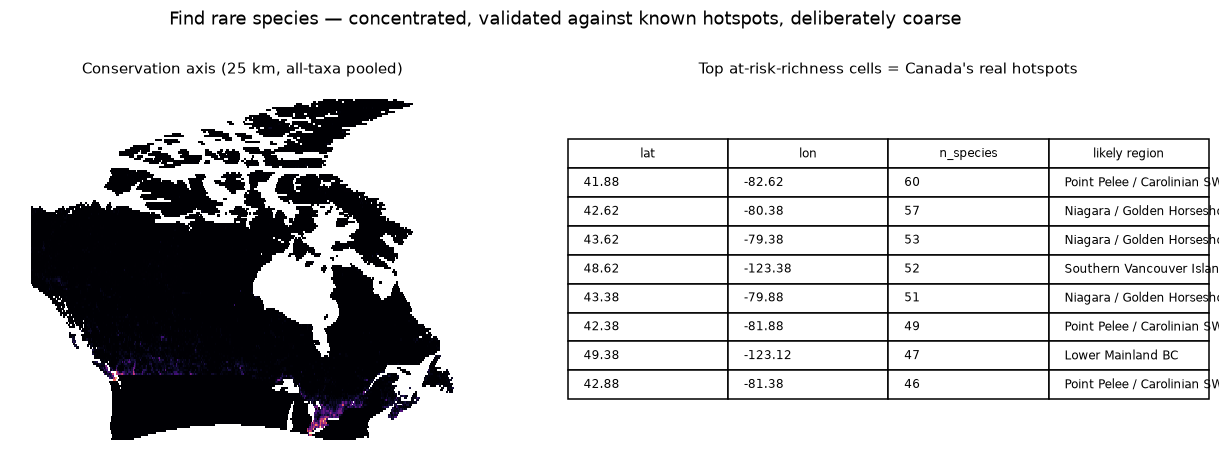

Caveat: reflects ASSESSED species only (CAN-SAR ~2021); IUCN/COSEWIC under-assess inverts, plants, fungi.


In [6]:
cons = pd.read_csv(CA / "ca_atrisk_richness.csv")
top = cons.nlargest(8, "n_species")[["lat", "lon", "n_species"]].reset_index(drop=True)

def name_place(lat, lon):
    spots = [("Point Pelee / Carolinian SW Ontario", 42.0, -82.5),
             ("Southern Vancouver Island / Garry Oak", 48.5, -123.4),
             ("Okanagan", 49.9, -119.5), ("Lower Mainland BC", 49.2, -122.5),
             ("Niagara / Golden Horseshoe", 43.1, -79.4), ("Montréal / St. Lawrence", 45.5, -73.6)]
    return min(spots, key=lambda s: (s[1]-lat)**2 + (s[2]-lon)**2)[0]
top["likely region"] = [name_place(r.lat, r.lon) for r in top.itertuples()]

fig, axs = plt.subplots(1, 2, figsize=(12, 4.2))
canada_map(axs[0], ALL["conservation"], "Conservation axis (25 km, all-taxa pooled)", cmap="magma")
axs[1].axis("off")
axs[1].set_title("Top at-risk-richness cells = Canada's real hotspots", fontsize=10)
tbl = axs[1].table(cellText=top.round(2).values, colLabels=top.columns, loc="center", cellLoc="left")
tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1, 1.5)
fig.suptitle("Find rare species — concentrated, validated against known hotspots, deliberately coarse", y=1.0)
plt.tight_layout(); plt.show()
print("Caveat: reflects ASSESSED species only (CAN-SAR ~2021); IUCN/COSEWIC under-assess inverts, plants, fungi.")

### 3.3 · Cover every habitat — climate surprisal

**Measures:** how under-sampled a cell's *climate type* is (not its location).
**Formula:** in 3-D CHELSA climate space (temperature, seasonality, precipitation), estimate
how densely *recorded* places resemble this cell's climate via a density-weighted Gaussian
kernel; `env = −log(weighted climate density)`, percentile-ranked 0–1.

**The choice:** geographic gap ≠ environmental gap. A cell can be near a city yet sit in a
climate type almost nobody records. Scoring "climate surprisal" rather than distance keeps the
axis genuinely distinct from `discover` (we verify that distinctness in Section 6).

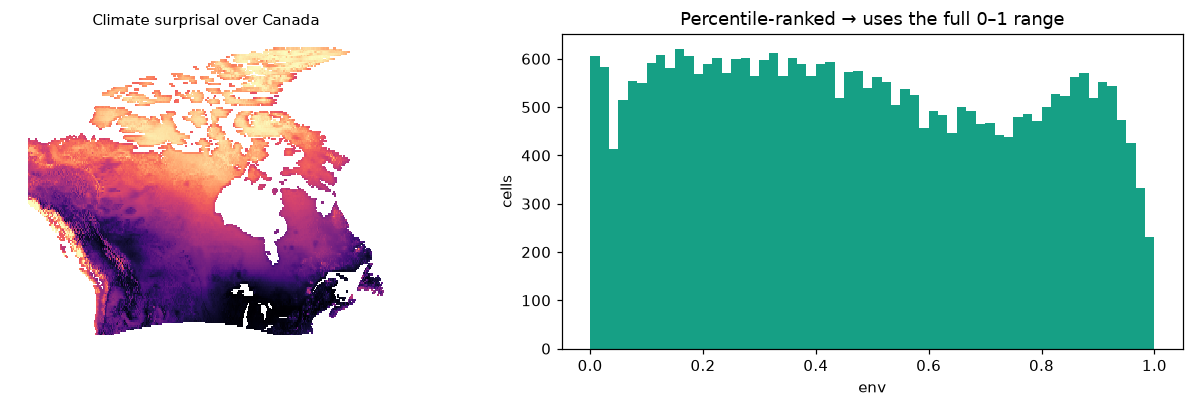

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(12, 3.8))
canada_map(axs[0], ALL["env"], "Climate surprisal over Canada", cmap="magma")
axs[1].hist(ALL["env"], bins=60, color="#16a085")
axs[1].set_title("Percentile-ranked → uses the full 0–1 range"); axs[1].set_xlabel("env"); axs[1].set_ylabel("cells")
plt.tight_layout(); plt.show()

### 3.4 · Freshest gaps — and the **iNat-only data-integrity choice**

**Measures:** cells well-recorded *historically* on iNaturalist but *quiet recently* — worth
revisiting. **Formula:** for cells with ≥20 historical records,
`staleness = (1 − n_recent/n_all) · log(1 + n_all)`, min–max 0–1.

**The choice, caught by cross-validation.** An earlier version sourced this from GBIF density.
But GBIF blends iNaturalist + eBird + museum specimens — eBird's recent bird volume and museums'
old specimens distort "where *iNaturalist users* have gone quiet." A cluster cross-validation
against the raw iNat dump found the GBIF signal was null (ρ ≈ −0.065) and the axis was
**re-sourced to iNaturalist-only**. This is the discipline the project runs on: an
un-validated layer is not trusted into the map.

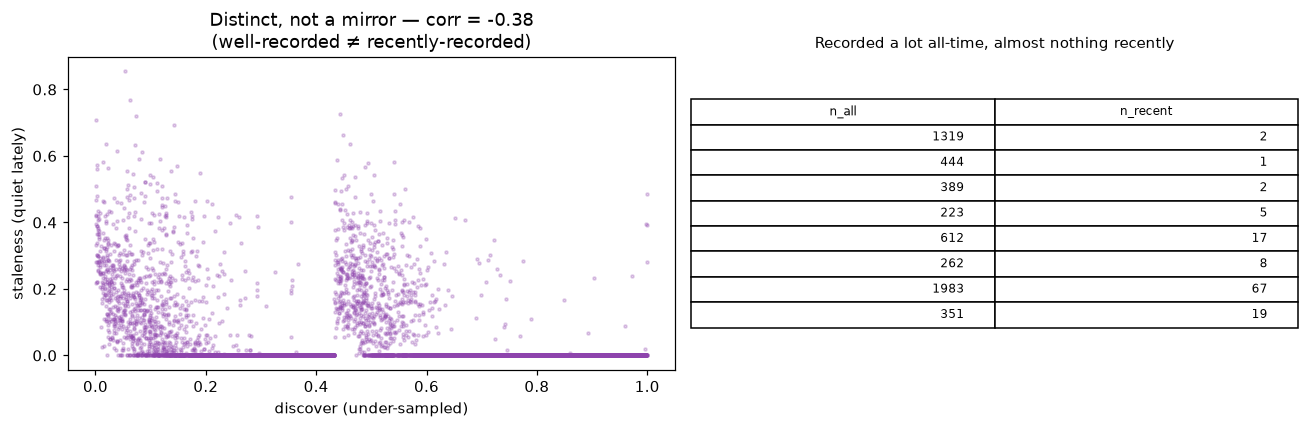

In [8]:
met = pd.read_csv(CA / "ca_inat_metrics.csv")
# Show staleness is a genuinely distinct signal, and surface a concrete "quiet now" cell.
fig, axs = plt.subplots(1, 2, figsize=(12, 4.0))
s = ALL.sample(6000, random_state=0)
axs[0].scatter(s["discover"], s["staleness"], s=4, alpha=0.25, color="#8e44ad")
axs[0].set_xlabel("discover (under-sampled)"); axs[0].set_ylabel("staleness (quiet lately)")
r = np.corrcoef(ALL["discover"], ALL["staleness"])[0,1]
axs[0].set_title(f"Distinct, not a mirror — corr = {r:+.2f}\n(well-recorded ≠ recently-recorded)")
busy_then_quiet = met[(met.n_all >= 200)].assign(recent_frac=lambda d: d.n_recent/d.n_all).nsmallest(8, "recent_frac")
axs[1].axis("off"); axs[1].set_title("Recorded a lot all-time, almost nothing recently", fontsize=10)
show = busy_then_quiet[["lat","lon","n_all","n_recent"]].round(2) if "lat" in busy_then_quiet else busy_then_quiet[["n_all","n_recent"]]
t = axs[1].table(cellText=show.values, colLabels=show.columns, loc="center"); t.auto_set_font_size(False); t.set_fontsize(8); t.scale(1,1.5)
plt.tight_layout(); plt.show()

### 3.5 · Sample before it's lost — recent habitat change

**Measures:** recent forest-cover loss — record before it's gone. **Formula:**
`urgency = normalize(Hansen forest-loss fraction)`, 0–1. High = recent loss (logging, fire,
dieback — Hansen measures loss of any cause, deliberately *not* labelled "deforestation").
The Fort McMurray fire scar scores ~0.75; saturated southern cities ~0.

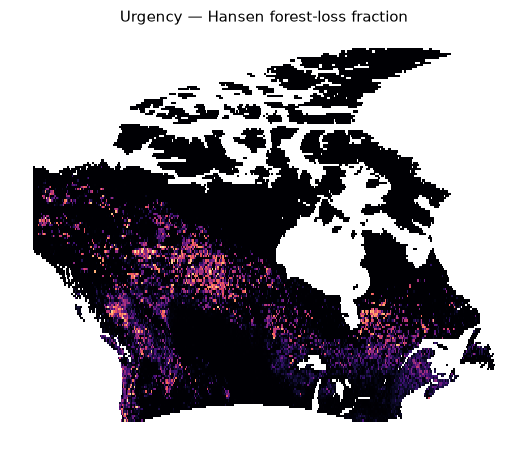

Fort McMurray-area cell urgency = 0.75  (vs national median 0.000)


In [9]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
canada_map(ax, ALL["urgency"], "Urgency — Hansen forest-loss fraction", cmap="magma")
plt.tight_layout(); plt.show()
fm = ALL.iloc[((ALL.lat-56.7)**2 + (ALL.lon+111.4)**2).idxmin()]
print(f"Fort McMurray-area cell urgency = {fm.urgency:.2f}  (vs national median {ALL.urgency.median():.3f})")

## 4 · The composite "impact" — the **percentile-rank choice**

You set a weight 0–1 per axis; per cell `raw_impact = Σ wᵢ · axisᵢ`. The number shown is
**not** that raw value — it's its **percentile rank** across the cells in view.

**Why this is the most important single choice in the app.** A handful of Arctic
"super-gaps" (max discover *and* rare climate) have enormous raw impact. Under a min–max
scale they stretch the colour ramp so every reachable southern cell collapses to ~0/100 —
the map tells a planner "nowhere near you matters," which is both false and useless. A
percentile rank spends the whole 0–100 range on the cells actually in view. The figure shows
the same weighted impact under both scalings.

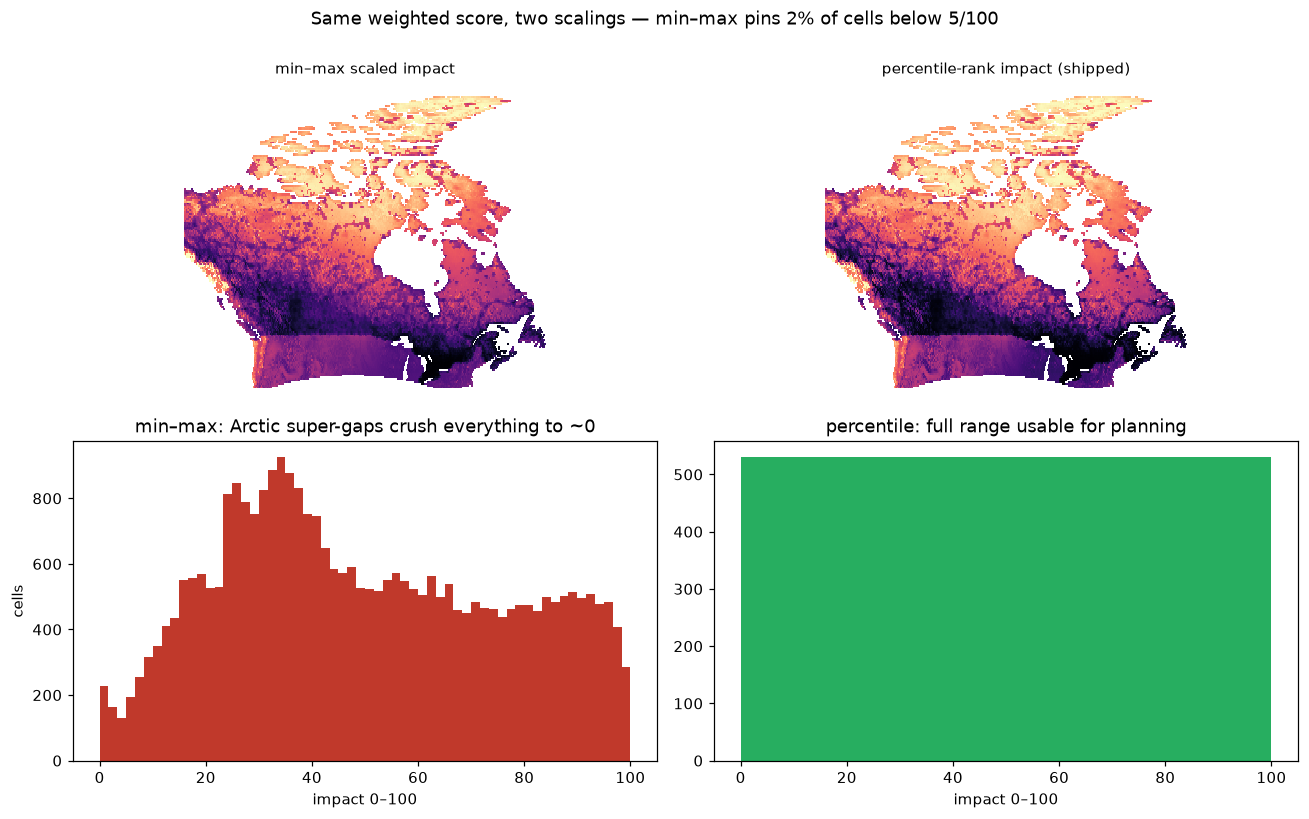

In [10]:
DEFAULT_W = {"discover": 0.8, "conservation": 0.0, "env": 0.7, "staleness": 0.0, "urgency": 0.3}  # 'Biodiversity impact' preset
raw = sum(DEFAULT_W[a] * ALL[a].to_numpy(float) for a in AXES)
minmax = (raw - raw.min()) / (raw.max() - raw.min()) * 100
order = raw.argsort(); pct = np.empty_like(raw); pct[order] = np.linspace(0, 100, len(raw))

fig, axs = plt.subplots(2, 2, figsize=(12, 7.4))
canada_map(axs[0,0], minmax, "min–max scaled impact", cmap="magma", vmax=100)
canada_map(axs[0,1], pct,    "percentile-rank impact (shipped)", cmap="magma", vmax=100)
axs[1,0].hist(minmax, bins=60, color="#c0392b"); axs[1,0].set_title("min–max: Arctic super-gaps crush everything to ~0"); axs[1,0].set_xlabel("impact 0–100"); axs[1,0].set_ylabel("cells")
axs[1,1].hist(pct, bins=60, color="#27ae60"); axs[1,1].set_title("percentile: full range usable for planning"); axs[1,1].set_xlabel("impact 0–100")
crushed = (minmax < 5).mean()
fig.suptitle(f"Same weighted score, two scalings — min–max pins {crushed*100:.0f}% of cells below 5/100", y=1.0)
plt.tight_layout(); plt.show()

## 5 · Presets — value choices, made explicit and linked to real challenges

A where-to-go map is a *value choice*, not a measurement: discovery, conservation, and
habitat coverage point to different places. Rather than hide that behind one "best" map, the
app ships the axes as sliders and offers named presets, **each linked to a real, verified
Blitz the Gap iNaturalist sub-project** so the planning tool and the campaign stay in sync.

,preset,discover,conservation,env,staleness,urgency,iNat project
0,Biodiversity impact,0.8,0,0.7,0,0.3,blitz-the-gap-2026-general
1,The Other 99%,1.0,0,0.3,0,0.0,blitz-the-gap-the-other-99
2,Most Wanted,0.1,1,0.0,0,0.3,blitz-the-gap-canada-s-most-wanted
3,Too Hot to Handle,0.2,0,0.2,0,1.0,blitz-the-gap-too-hot-to-handle
4,Climate Gap,0.2,0,1.0,0,0.0,blitz-the-gap-closing-the-climate-gap
5,Revisit the Past,0.3,0,0.0,1,0.0,blitz-the-gap-revisiting-the-past


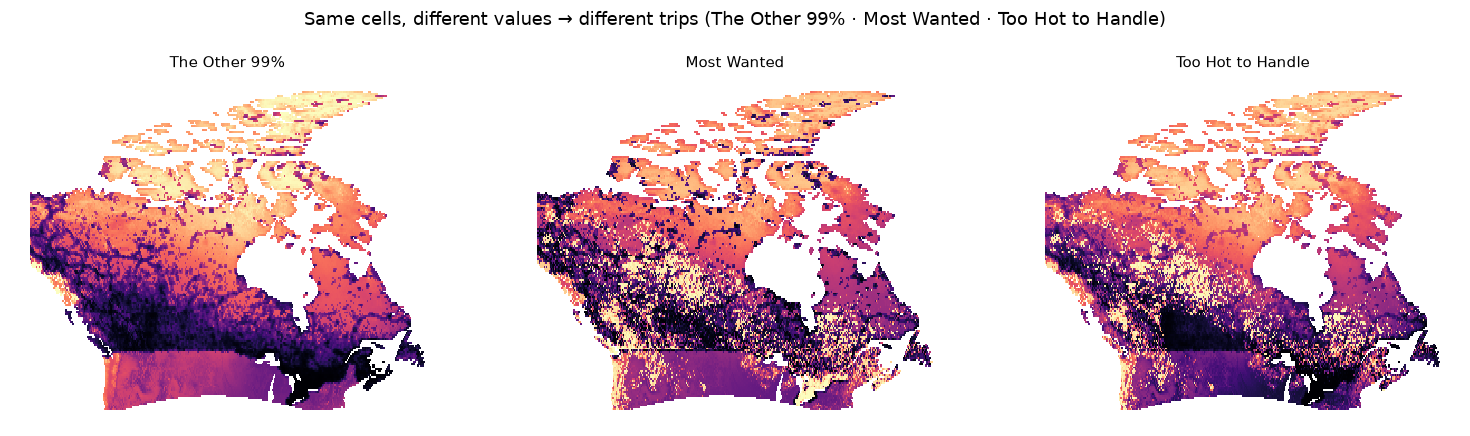

In [11]:
PRESETS = [
    ("Biodiversity impact", [0.8,0,0.7,0,0.3], "blitz-the-gap-2026-general"),
    ("The Other 99%",       [1,0,0.3,0,0],     "blitz-the-gap-the-other-99"),
    ("Most Wanted",         [0.1,1,0,0,0.3],   "blitz-the-gap-canada-s-most-wanted"),
    ("Too Hot to Handle",   [0.2,0,0.2,0,1],   "blitz-the-gap-too-hot-to-handle"),
    ("Climate Gap",         [0.2,0,1,0,0],     "blitz-the-gap-closing-the-climate-gap"),
    ("Revisit the Past",    [0.3,0,0,1,0],     "blitz-the-gap-revisiting-the-past"),
]
pd.set_option("display.max_colwidth", 60)
pdf = pd.DataFrame([(n, *w, proj) for n,w,proj in PRESETS], columns=["preset",*AXES,"iNat project"])
display(pdf)

# Two presets, two genuinely different maps — same geometry, different weighting.
def impact_pct(weights):
    raw = sum(weights[i]*ALL[AXES[i]].to_numpy(float) for i in range(5))
    o = raw.argsort(); p = np.empty_like(raw); p[o] = np.linspace(0,100,len(raw)); return p
fig, axs = plt.subplots(1, 3, figsize=(14, 3.8))
for ax,(name,w,_) in zip(axs, [PRESETS[1], PRESETS[2], PRESETS[3]]):
    canada_map(ax, impact_pct(w), name, cmap="magma", vmax=100)
fig.suptitle("Same cells, different values → different trips (The Other 99% · Most Wanted · Too Hot to Handle)", y=1.03)
plt.tight_layout(); plt.show()

## 6 · Do the axes actually disagree? (Why multi-objective is honest)

If the five axes were near-duplicates, the sliders would be theatre. They aren't. Below is
the Spearman rank-correlation between axes **computed over recorded cells only** (`n_train > 0`).

> A verification catch worth flagging: computed over the *full* grid, discover and env
> correlate ~0.9 — an artifact, because ~half the cells are zero-observation gaps that pin
> discover at its max, so it can't vary. Restricting to recorded cells gives the honest,
> negative relationship. The number you compute depends on the cells you include.

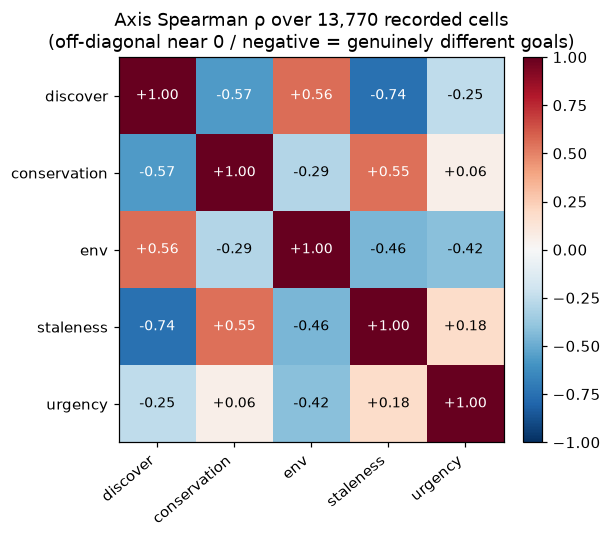

In [12]:
rec = ALL[ALL["n_train"] > 0]
M = rec[AXES].corr(method="spearman")
fig, ax = plt.subplots(figsize=(5.8, 5))
im = ax.imshow(M, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(5)); ax.set_yticks(range(5))
ax.set_xticklabels(AXES, rotation=40, ha="right"); ax.set_yticklabels(AXES)
for i in range(5):
    for j in range(5):
        ax.text(j, i, f"{M.iloc[i,j]:+.2f}", ha="center", va="center",
                color="white" if abs(M.iloc[i,j])>0.5 else "black", fontsize=9)
ax.set_title(f"Axis Spearman ρ over {len(rec):,} recorded cells\n(off-diagonal near 0 / negative = genuinely different goals)")
fig.colorbar(im, fraction=0.046, pad=0.04); plt.tight_layout(); plt.show()

## 7 · From map to trip — the planning choices

The map answers *where*; the planner answers *where can I actually get to and back, greenest*.
The choices here are about **cost and carbon, never about boosting the score**:

- **Accessibility is a cost denominator, not a booster.** Trips rank by `impact × field-time`,
  and travel time only ever *divides* — so the planner never re-creates roadside sampling bias
  by rewarding easy-to-reach cells. Remote gaps stay high-priority; they just cost more to reach.
- **Adaptive greenest mode.** The default travel mode is the greenest (Walk > Cycle > Drive)
  that can still reach a gap within your time budget — chosen from your start, not assumed.
- **Real routes, honest fallback.** Walk/Cycle/Drive routes come from OSRM; when a route can't
  be fetched it falls back to a straight-line estimate (×1.35 road factor) and the trip is
  *flagged as estimated*. Driving ≈ 0.18 kg CO₂/km; cycling/walking zero.
- **"Worth the drive."** A field:travel ratio floor (record ≥ half the time you drive) keeps the
  default trip from being 4 h of driving for 1 h of recording.

There is no figure here because this is interaction, not data — but it is the same discipline:
every default is a defensible choice, and the estimated cases are labelled as such.

## 8 · Does the central choice hold up? — directed beats opportunistic

The app's core bet is that **directing people to under-sampled cells discovers more new
species than letting them go where it's already busy.** That is a *prediction*, and it is
backtestable on public data alone — no need for the private parquet.

**Design of the test** (`backtest_appscore.py`, leakage-free): take the 2025 BC pilot
(iNat project 228908), split each cell's records at a date `T`. Build the priority axes from
**train-only** observations; score the outcome as **new-to-cell species** from **test-only**
observations. To kill the species-accumulation confound, rarefy every cell to a fixed `K = 5`
test observations. A positive Spearman ρ between an axis and post-split discovery means that
axis sends you to genuinely productive cells.

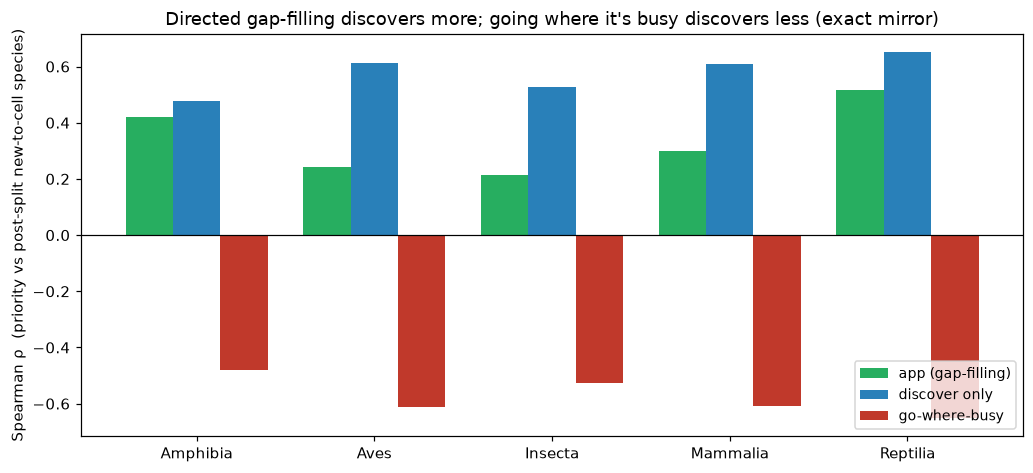

Mean ρ — app gap-filling priority : +0.34  (positive on 5/5 taxa)
Mean ρ — go-where-it's-busy       : -0.58  (the near-exact negative mirror)


In [13]:
app = json.load(open(RES / "voi_appscore_results.json"))
rows = []
for r in app:
    s = r["scores"]
    rows.append({"taxon": r["taxon"],
                 "app (gap-filling)": s["app_leakfree"]["spearman"],
                 "discover only":     s["discover_leakfree"]["spearman"],
                 "go-where-busy":     s["opportunistic_density"]["spearman"]})
bt = pd.DataFrame(rows).set_index("taxon")

fig, ax = plt.subplots(figsize=(9.5, 4.4))
bt.plot.bar(ax=ax, color=["#27ae60", "#2980b9", "#c0392b"], width=0.8)
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("Spearman ρ  (priority vs post-split new-to-cell species)")
ax.set_title("Directed gap-filling discovers more; going where it's busy discovers less (exact mirror)")
ax.legend(loc="lower right", fontsize=9); ax.set_xlabel("")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

m_app  = bt["app (gap-filling)"].mean()
m_busy = bt["go-where-busy"].mean()
print(f"Mean ρ — app gap-filling priority : {m_app:+.2f}  (positive on {bt['app (gap-filling)'].gt(0).sum()}/{len(bt)} taxa)")
print(f"Mean ρ — go-where-it's-busy       : {m_busy:+.2f}  (the near-exact negative mirror)")

**Two honest findings to highlight:**

1. **The signal is real but lives almost entirely in the under-sampling axis.** `discover` on
   its own matches or beats the full default preset; `env` and `urgency` are ~uncorrelated with
   *this* discovery objective (they optimise *other* goals by design). So the default
   `0.8·discover + 0.7·env + 0.3·urgency` slightly **dilutes** discovery — re-tuning the default
   toward discover is an open product decision, surfaced not silently "fixed."
2. **It replicates out of region.** Re-running on a disjoint Eastern-Canada window (ON/QC/
   Maritimes) reproduces the directed > opportunistic result — it is not a BC artifact.

In [14]:
# Replication on a disjoint region (Eastern Canada), same harness.
east = json.load(open(RES / "voi_appscore_east_results.json"))
er = pd.DataFrame([{"taxon": r["taxon"],
                    "app (gap-filling)": r["scores"]["app_leakfree"]["spearman"],
                    "go-where-busy":     r["scores"]["opportunistic_density"]["spearman"]}
                   for r in east]).set_index("taxon")
print("Eastern-Canada replication (disjoint from BC):")
display(er.round(2))
print(f"\nDirected stays positive on {er['app (gap-filling)'].gt(0).sum()}/{len(er)} eastern taxa → not a regional artifact.")

Eastern-Canada replication (disjoint from BC):


,app (gap-filling),go-where-busy
taxon,,
Aves,0.37,-0.58
Insecta,0.30,-0.47
Mammalia,0.52,-0.69



Directed stays positive on 3/3 eastern taxa → not a regional artifact.


## 9 · Responsible use — guardrails as design, not disclaimer

These constraints shaped the contents above; they are the reason some things are *coarse* or
*absent* on purpose:

- **Species-at-risk are gated out of suggestions.** Every live iNaturalist fetch carries
  `taxon_geoprivacy=open` and the "fill the gap" suggestions add `threatened=false`. The tool
  will not point a stranger at a rare orchid.
- **The conservation axis is coarse by design** (Section 3.2) — a 25 km, all-taxa sum, never
  a species map. Dual-use mitigation (Pollock et al. 2025, Box 3) stays in force for any
  finer future layer.
- **Indigenous data sovereignty.** Obscure sensitive locations and respect
  [Indigenous data sovereignty](https://native-land.ca) before any public use; a territory
  acknowledgment is linked in-app.
- **It is a prototype, flagged in-app**, and a *planning aid, not a census*. iNaturalist counts
  are sampling effort, not ground-truth abundance, and are labelled that way throughout.

## 10 · Reproduce everything

```bash
# 1. environment (no credentials needed; all sources public)
uv venv --python 3.11 .venv && uv pip install --python .venv/bin/python -r requirements.txt

# 2. regenerate the national build from cluster_results/ca/ (deterministic, byte-identical)
.venv/bin/python build_webapp.py          # → index.html

# 3. rebuild + execute THIS walkthrough
.venv/bin/python _build_walkthrough.py
.venv/bin/jupyter nbconvert --to notebook --execute --inplace where-to-blitz-walkthrough.ipynb
```

The build is frozen by a manifest hash (printed in Section 1); the validation results read from
cached `cluster_results/*.json`, re-pullable with `pull_inat_backtest.py`. Optional live cell
below shows the *"tap a cell → what to record"* loop on today's iNaturalist data.

In [15]:
# OPTIONAL — live iNaturalist "fill the gap" near a chosen cell. Guarded: skips cleanly offline.
import urllib.request
def fill_the_gap(lat, lon, radius_km=25):
    url = ("https://api.inaturalist.org/v1/observations/species_counts"
           f"?lat={lat}&lng={lon}&radius={radius_km}&quality_grade=research"
           "&taxon_geoprivacy=open&threatened=false&per_page=5")
    with urllib.request.urlopen(url, timeout=8) as r:
        return json.load(r)
try:
    # pick the highest-priority reachable-ish CANADIAN cell under the default preset
    # (exclude the clearly-US band from §2.1 so the demo stays on-mission)
    cand = ALL.assign(imp=pct, usw=us_west.to_numpy()).query("travel_min < 600 and not usw")
    cell = cand.nlargest(1, "imp").iloc[0]
    print(f"Top reachable gap under default preset: ({cell.lat:.2f}, {cell.lon:.2f})  impact≈{cell.imp:.0f}/100")
    res = fill_the_gap(cell.lat, cell.lon)
    print(f"iNaturalist shows {res['total_results']:,} research-grade species in the surrounding 25 km. Sample:")
    for t in res["results"][:5]:
        print(f"  • {t['taxon'].get('preferred_common_name', t['taxon']['name'])}  ({t['count']} obs)")
except Exception as e:
    print(f"(live iNaturalist call skipped — offline or rate-limited: {type(e).__name__})")

Top reachable gap under default preset: (55.88, -106.62)  impact≈64/100


iNaturalist shows 12 research-grade species in the surrounding 25 km. Sample:
  • Red Fox  (1 obs)
  • orange peel fungus  (1 obs)
  • narrowleaf cow wheat  (1 obs)
  • long-leaved bluets  (1 obs)
  • American parsley fern  (1 obs)


---
*Built deterministically by `_build_walkthrough.py` from the committed where-to-blitz build.
Every number traces to a file in `cluster_results/`; nothing is from memory. Prototype, not
official, not ground truth.*